In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42

DATA_PATH = Path('cleaned_flight_data.csv')
OUT_DIR = Path('unsupervised_flight_outputs')
OUT_DIR.mkdir(exist_ok=True)

In [2]:
weather_cols = [
    'origin_temp','origin_dwpt','origin_rhum','origin_prcp','origin_snow','origin_wspd','origin_pres','origin_coco',
    'dest_temp','dest_dwpt','dest_rhum','dest_prcp','dest_snow','dest_wspd','dest_pres','dest_coco'
]

keep_cols = [
    'FlightDate','Operating_Airline','IATA_Code_Operating_Airline','Origin','Dest','route','DepDel15','Distance',
    'sched_dep_hour','sched_dep_minutes_since_midnight','DayOfWeek','Month','is_weekend'
] + weather_cols

TIME_BINS = [-1, 4, 7, 11, 15, 19, 23]
TIME_LABELS = ['overnight', 'early_morning', 'morning', 'afternoon', 'evening', 'night']


def weather_flags(df):
    df = df.copy()
    for c in ['origin_prcp','dest_prcp','origin_snow','dest_snow','origin_wspd','dest_wspd','origin_rhum','dest_rhum']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    wind_threshold = pd.concat([df['origin_wspd'], df['dest_wspd']], axis=0).quantile(0.75)

    df['origin_bad_weather'] = (
        (df['origin_prcp'].fillna(0) > 0) |
        (df['origin_snow'].fillna(0) > 0) |
        (df['origin_wspd'].fillna(0) >= wind_threshold)
    ).astype(int)

    df['dest_bad_weather'] = (
        (df['dest_prcp'].fillna(0) > 0) |
        (df['dest_snow'].fillna(0) > 0) |
        (df['dest_wspd'].fillna(0) >= wind_threshold)
    ).astype(int)

    df['any_bad_weather'] = ((df['origin_bad_weather'] == 1) | (df['dest_bad_weather'] == 1)).astype(int)
    df['night_or_late_flight'] = pd.to_numeric(df['sched_dep_hour'], errors='coerce').fillna(-1).between(18, 23).astype(int)
    df['morning_flight'] = pd.to_numeric(df['sched_dep_hour'], errors='coerce').fillna(-1).between(5, 11).astype(int)

    df['time_of_day'] = pd.cut(
        pd.to_numeric(df['sched_dep_hour'], errors='coerce'),
        bins=TIME_BINS,
        labels=TIME_LABELS
    ).astype(str)
    df.loc[df['time_of_day'].eq('nan'), 'time_of_day'] = 'unknown'
    return df


df = pd.read_csv(DATA_PATH, low_memory=False)
available_cols = [c for c in keep_cols if c in df.columns]
df = df[available_cols].copy()

for c in df.columns:
    if c not in ['FlightDate','Operating_Airline','IATA_Code_Operating_Airline','Origin','Dest','route']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Fill airline names and create a route field if needed.
df['Operating_Airline'] = df['Operating_Airline'].fillna(df.get('IATA_Code_Operating_Airline')).astype(str)
if 'route' not in df.columns or df['route'].isna().all():
    df['route'] = df['Origin'].astype(str) + '-' + df['Dest'].astype(str)
df['route'] = df['route'].fillna(df['Origin'].astype(str) + '-' + df['Dest'].astype(str))

# Keep usable rows only.
df = df.dropna(subset=['DepDel15','Origin','Dest','Operating_Airline','route'])
df['DepDel15'] = df['DepDel15'].astype(int)
df = weather_flags(df)

print('Rows:', len(df))
print('Columns:', len(df.columns))
df.head()

Rows: 26119
Columns: 35


,FlightDate,Operating_Airline,IATA_Code_Operating_Airline,Origin,Dest,route,DepDel15,Distance,sched_dep_hour,sched_dep_minutes_since_midnight,...,dest_snow,dest_wspd,dest_pres,dest_coco,origin_bad_weather,dest_bad_weather,any_bad_weather,night_or_late_flight,morning_flight,time_of_day
0,2026-01-08,G7,G7,ORD,ABE,ORD_ABE,1,654.0,13,802,...,NaN,5.5,1022.0,1.0,0,0,0,0,0,afternoon
1,2026-01-08,G7,G7,ORD,ATW,ORD_ATW,1,160.0,20,1215,...,NaN,7.0,1004.0,3.0,0,0,0,1,0,night
2,2026-01-08,G7,G7,ORD,BHM,ORD_BHM,0,584.0,11,665,...,NaN,5.5,1019.0,4.0,0,0,0,0,1,morning
3,2026-01-08,G7,G7,ORD,CMH,ORD_CMH,0,296.0,14,857,...,NaN,9.0,1020.0,5.0,0,0,0,0,0,afternoon
4,2026-01-08,G7,G7,ORD,SGF,ORD_SGF,0,438.0,12,765,...,NaN,25.9,1006.0,3.0,0,1,1,0,0,afternoon


In [3]:
def add_weather_sensitivity(base_agg, df, group_cols, weather_col='any_bad_weather'):
    sens = df.groupby(group_cols, observed=True).apply(lambda x: pd.Series({
        'bad_weather_delay_rate': x.loc[x[weather_col] == 1, 'DepDel15'].mean() if (x[weather_col] == 1).any() else np.nan,
        'normal_weather_delay_rate': x.loc[x[weather_col] == 0, 'DepDel15'].mean() if (x[weather_col] == 0).any() else np.nan,
    })).reset_index()
    out = base_agg.merge(sens, on=group_cols, how='left')
    out['weather_delay_sensitivity'] = out['bad_weather_delay_rate'] - out['normal_weather_delay_rate']
    return out


def aggregate_airports(df):
    origin = df.rename(columns={
        'Origin':'airport','Dest':'other_airport',
        'origin_temp':'temp','origin_rhum':'rhum','origin_prcp':'prcp','origin_snow':'snow','origin_wspd':'wspd','origin_pres':'pres','origin_coco':'coco',
        'origin_bad_weather':'bad_weather'
    }).assign(direction='origin')
    dest = df.rename(columns={
        'Dest':'airport','Origin':'other_airport',
        'dest_temp':'temp','dest_rhum':'rhum','dest_prcp':'prcp','dest_snow':'snow','dest_wspd':'wspd','dest_pres':'pres','dest_coco':'coco',
        'dest_bad_weather':'bad_weather'
    }).assign(direction='dest')
    cols = ['airport','other_airport','Operating_Airline','DepDel15','Distance','bad_weather','temp','rhum','prcp','snow','wspd','pres','coco','night_or_late_flight','morning_flight','is_weekend','time_of_day']
    long_df = pd.concat([origin[cols], dest[cols]], ignore_index=True)

    g = long_df.groupby('airport', observed=True)
    agg = g.agg(
        total_flights=('DepDel15','size'),
        delay_rate=('DepDel15','mean'),
        avg_distance=('Distance','mean'),
        airlines_served=('Operating_Airline','nunique'),
        connected_airports=('other_airport','nunique'),
        bad_weather_share=('bad_weather','mean'),
        avg_temp=('temp','mean'),
        avg_humidity=('rhum','mean'),
        avg_precipitation=('prcp','mean'),
        snow_share=('snow', lambda s: (pd.to_numeric(s, errors='coerce').fillna(0) > 0).mean()),
        avg_wind_speed=('wspd','mean'),
        avg_pressure=('pres','mean'),
        late_flight_share=('night_or_late_flight','mean'),
        morning_flight_share=('morning_flight','mean'),
        weekend_share=('is_weekend','mean'),
    ).reset_index()

    sens = long_df.groupby('airport', observed=True).apply(lambda x: pd.Series({
        'bad_weather_delay_rate': x.loc[x['bad_weather']==1, 'DepDel15'].mean() if (x['bad_weather']==1).any() else np.nan,
        'normal_weather_delay_rate': x.loc[x['bad_weather']==0, 'DepDel15'].mean() if (x['bad_weather']==0).any() else np.nan,
    })).reset_index()

    agg = agg.merge(sens, on='airport', how='left')
    agg['weather_delay_sensitivity'] = agg['bad_weather_delay_rate'] - agg['normal_weather_delay_rate']
    return agg[agg['total_flights'] >= 20].copy()


def aggregate_airlines(df):
    g = df.groupby('Operating_Airline', observed=True)
    agg = g.agg(
        total_flights=('DepDel15','size'),
        delay_rate=('DepDel15','mean'),
        avg_distance=('Distance','mean'),
        airports_served=('Origin', lambda s: pd.concat([s, df.loc[s.index, 'Dest']]).nunique()),
        routes_served=('route','nunique'),
        bad_weather_share=('any_bad_weather','mean'),
        avg_origin_wind=('origin_wspd','mean'),
        avg_dest_wind=('dest_wspd','mean'),
        avg_origin_precip=('origin_prcp','mean'),
        avg_dest_precip=('dest_prcp','mean'),
        late_flight_share=('night_or_late_flight','mean'),
        morning_flight_share=('morning_flight','mean'),
        weekend_share=('is_weekend','mean')
    ).reset_index()
    agg = add_weather_sensitivity(agg, df, ['Operating_Airline'])
    return agg[agg['total_flights'] >= 20].copy()


def aggregate_routes(df):
    g = df.groupby('route', observed=True)
    agg = g.agg(
        total_flights=('DepDel15','size'),
        delay_rate=('DepDel15','mean'),
        avg_distance=('Distance','mean'),
        airlines_on_route=('Operating_Airline','nunique'),
        origin_bad_weather_share=('origin_bad_weather','mean'),
        dest_bad_weather_share=('dest_bad_weather','mean'),
        any_bad_weather_share=('any_bad_weather','mean'),
        avg_origin_wind=('origin_wspd','mean'),
        avg_dest_wind=('dest_wspd','mean'),
        avg_origin_precip=('origin_prcp','mean'),
        avg_dest_precip=('dest_prcp','mean'),
        late_flight_share=('night_or_late_flight','mean'),
        morning_flight_share=('morning_flight','mean'),
        weekend_share=('is_weekend','mean'),
    ).reset_index()
    agg = add_weather_sensitivity(agg, df, ['route'])
    return agg[agg['total_flights'] >= 10].copy()

Aggregate Airports, Routes, and Route level features

In [4]:
def aggregate_time_of_day(df):
    g = df.groupby('time_of_day', observed=True)
    agg = g.agg(
        total_flights=('DepDel15','size'),
        delay_rate=('DepDel15','mean'),
        avg_distance=('Distance','mean'),
        airlines_served=('Operating_Airline','nunique'),
        routes_served=('route','nunique'),
        any_bad_weather_share=('any_bad_weather','mean'),
        avg_origin_wind=('origin_wspd','mean'),
        avg_dest_wind=('dest_wspd','mean'),
        avg_origin_precip=('origin_prcp','mean'),
        avg_dest_precip=('dest_prcp','mean'),
        weekend_share=('is_weekend','mean')
    ).reset_index()
    agg = add_weather_sensitivity(agg, df, ['time_of_day'])
    return agg[agg['total_flights'] >= 20].copy()


def aggregate_airport_time(df):
    origin = df.rename(columns={
        'Origin':'airport','Dest':'other_airport',
        'origin_prcp':'prcp','origin_snow':'snow','origin_wspd':'wspd','origin_bad_weather':'bad_weather'
    }).assign(direction='origin')
    dest = df.rename(columns={
        'Dest':'airport','Origin':'other_airport',
        'dest_prcp':'prcp','dest_snow':'snow','dest_wspd':'wspd','dest_bad_weather':'bad_weather'
    }).assign(direction='dest')
    cols = ['airport','time_of_day','other_airport','Operating_Airline','route','DepDel15','Distance','bad_weather','prcp','snow','wspd','is_weekend']
    long_df = pd.concat([origin[cols], dest[cols]], ignore_index=True)

    g = long_df.groupby(['airport','time_of_day'], observed=True)
    agg = g.agg(
        total_flights=('DepDel15','size'),
        delay_rate=('DepDel15','mean'),
        avg_distance=('Distance','mean'),
        airlines_served=('Operating_Airline','nunique'),
        routes_served=('route','nunique'),
        connected_airports=('other_airport','nunique'),
        bad_weather_share=('bad_weather','mean'),
        avg_precipitation=('prcp','mean'),
        snow_share=('snow', lambda s: (pd.to_numeric(s, errors='coerce').fillna(0) > 0).mean()),
        avg_wind_speed=('wspd','mean'),
        weekend_share=('is_weekend','mean')
    ).reset_index()

    sens = long_df.groupby(['airport','time_of_day'], observed=True).apply(lambda x: pd.Series({
        'bad_weather_delay_rate': x.loc[x['bad_weather']==1, 'DepDel15'].mean() if (x['bad_weather']==1).any() else np.nan,
        'normal_weather_delay_rate': x.loc[x['bad_weather']==0, 'DepDel15'].mean() if (x['bad_weather']==0).any() else np.nan,
    })).reset_index()

    agg = agg.merge(sens, on=['airport','time_of_day'], how='left')
    agg['weather_delay_sensitivity'] = agg['bad_weather_delay_rate'] - agg['normal_weather_delay_rate']
    agg['airport_time'] = agg['airport'].astype(str) + '_' + agg['time_of_day'].astype(str)
    return agg[agg['total_flights'] >= 10].copy()


def aggregate_airline_time(df):
    g = df.groupby(['Operating_Airline','time_of_day'], observed=True)
    agg = g.agg(
        total_flights=('DepDel15','size'),
        delay_rate=('DepDel15','mean'),
        avg_distance=('Distance','mean'),
        routes_served=('route','nunique'),
        origins_served=('Origin','nunique'),
        destinations_served=('Dest','nunique'),
        any_bad_weather_share=('any_bad_weather','mean'),
        avg_origin_wind=('origin_wspd','mean'),
        avg_dest_wind=('dest_wspd','mean'),
        avg_origin_precip=('origin_prcp','mean'),
        avg_dest_precip=('dest_prcp','mean'),
        weekend_share=('is_weekend','mean')
    ).reset_index()
    agg = add_weather_sensitivity(agg, df, ['Operating_Airline','time_of_day'])
    agg['airline_time'] = agg['Operating_Airline'].astype(str) + '_' + agg['time_of_day'].astype(str)
    return agg[agg['total_flights'] >= 10].copy()


def aggregate_route_airline_time(df):
    g = df.groupby(['route','Operating_Airline','time_of_day'], observed=True)
    agg = g.agg(
        total_flights=('DepDel15','size'),
        delay_rate=('DepDel15','mean'),
        avg_distance=('Distance','mean'),
        any_bad_weather_share=('any_bad_weather','mean'),
        origin_bad_weather_share=('origin_bad_weather','mean'),
        dest_bad_weather_share=('dest_bad_weather','mean'),
        avg_origin_wind=('origin_wspd','mean'),
        avg_dest_wind=('dest_wspd','mean'),
        avg_origin_precip=('origin_prcp','mean'),
        avg_dest_precip=('dest_prcp','mean'),
        weekend_share=('is_weekend','mean')
    ).reset_index()
    agg = add_weather_sensitivity(agg, df, ['route','Operating_Airline','time_of_day'])
    agg['route_airline_time'] = agg['route'].astype(str) + '_' + agg['Operating_Airline'].astype(str) + '_' + agg['time_of_day'].astype(str)
    return agg[agg['total_flights'] >= 10].copy()


def aggregate_weather_sensitivity(df):
    # Route-level weather-focused model.
    g = df.groupby('route', observed=True)
    agg = g.agg(
        total_flights=('DepDel15','size'),
        delay_rate=('DepDel15','mean'),
        any_bad_weather_share=('any_bad_weather','mean'),
        origin_bad_weather_share=('origin_bad_weather','mean'),
        dest_bad_weather_share=('dest_bad_weather','mean'),
        avg_origin_precip=('origin_prcp','mean'),
        avg_dest_precip=('dest_prcp','mean'),
        avg_origin_snow=('origin_snow','mean'),
        avg_dest_snow=('dest_snow','mean'),
        avg_origin_wind=('origin_wspd','mean'),
        avg_dest_wind=('dest_wspd','mean'),
        avg_origin_humidity=('origin_rhum','mean'),
        avg_dest_humidity=('dest_rhum','mean'),
        late_flight_share=('night_or_late_flight','mean'),
        morning_flight_share=('morning_flight','mean')
    ).reset_index()
    agg = add_weather_sensitivity(agg, df, ['route'])
    return agg[agg['total_flights'] >= 10].copy()

In [5]:
def prepare_features(agg, id_col):
    data = agg.copy()
    data['log_total_flights'] = np.log1p(data['total_flights'])

    drop_cols = [id_col, 'total_flights']
    features = [
        c for c in data.columns
        if c not in drop_cols and pd.api.types.is_numeric_dtype(data[c])
    ]

    X = data[features].replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True)).fillna(0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return data, features, X, X_scaled, scaler


def evaluate_kmeans(X_scaled, k_min=2, k_max=8):
    max_k = min(k_max, len(X_scaled) - 1)
    rows, models = [], {}

    for k in range(k_min, max_k + 1):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, algorithm='lloyd')
        labels = km.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else np.nan
        rows.append({'k': k, 'silhouette_score': score, 'inertia': km.inertia_})
        models[k] = km

    scores = pd.DataFrame(rows)
    best_k = int(scores.sort_values(['silhouette_score', 'k'], ascending=[False, True]).iloc[0]['k'])
    return scores, best_k, models[best_k]


def evaluate_hierarchical(X_scaled, k_min=2, k_max=8):
    max_k = min(k_max, len(X_scaled) - 1)
    rows, labels_by_k = [], {}

    for k in range(k_min, max_k + 1):
        hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = hc.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else np.nan
        rows.append({'k': k, 'silhouette_score': score})
        labels_by_k[k] = labels

    scores = pd.DataFrame(rows)
    best_k = int(scores.sort_values(['silhouette_score', 'k'], ascending=[False, True]).iloc[0]['k'])
    return scores, best_k, labels_by_k[best_k]

In [6]:
def save_cluster_heatmap(data, features, name):
    profile_for_heatmap = data.groupby('kmeans_cluster')[features].mean()

    # Standardize cluster means so each feature is comparable on the same color scale.
    profile_scaled = pd.DataFrame(
        StandardScaler().fit_transform(profile_for_heatmap),
        index=profile_for_heatmap.index,
        columns=profile_for_heatmap.columns
    )

    plt.figure(figsize=(max(10, len(features) * 0.55), 4.5))
    plt.imshow(profile_scaled, aspect='auto')
    plt.colorbar(label='Standardized feature value')
    plt.xticks(range(len(profile_scaled.columns)), profile_scaled.columns, rotation=90)
    plt.yticks(range(len(profile_scaled.index)), [f'Cluster {i}' for i in profile_scaled.index])
    plt.title(f'{name.title()} K-Means Cluster Profile Heatmap')
    plt.xlabel('Features')
    plt.ylabel('Cluster')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'{name}_kmeans_cluster_profile_heatmap.png', dpi=150)
    plt.show()


def save_pca_plot(X_scaled, data, name):
    if len(data) < 3 or X_scaled.shape[1] < 2:
        return

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data['kmeans_cluster'], alpha=0.7)
    plt.title(f'{name.title()} K-Means Clusters PCA View')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.colorbar(scatter, label='K-Means Cluster')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'{name}_kmeans_pca_clusters.png', dpi=150)
    plt.show()
def save_hierarchical_dendrogram(X_scaled, name, max_sample=200):
    """Save a hierarchical clustering dendrogram using a manageable sample."""
    if len(X_scaled) < 3:
        return

    sample_size = min(max_sample, len(X_scaled))
    idx = np.linspace(0, len(X_scaled) - 1, sample_size, dtype=int)

    Z = linkage(X_scaled[idx], method='ward')

    plt.figure(figsize=(10, 5))
    dendrogram(Z, no_labels=True, truncate_mode='lastp', p=min(30, sample_size))
    plt.title(f'{name.title()} Hierarchical Clustering Dendrogram')
    plt.xlabel('Clustered entities')
    plt.ylabel('Ward distance')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'{name}_hierarchical_dendrogram.png', dpi=150)
    plt.show()


def save_hierarchical_pca_plot(X_scaled, data, name):
    """Save a PCA scatterplot colored by hierarchical cluster labels."""
    if len(data) < 3 or X_scaled.shape[1] < 2:
        return

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data['hierarchical_cluster'], alpha=0.7)
    plt.title(f'{name.title()} Hierarchical Clusters PCA View')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    plt.colorbar(scatter, label='Hierarchical Cluster')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'{name}_hierarchical_pca_clusters.png', dpi=150)
    plt.show()


In [ ]:
def cluster_and_save(agg, id_col, name):
    data, features, X, X_scaled, scaler = prepare_features(agg, id_col)

    kmeans_scores, best_k, km = evaluate_kmeans(X_scaled)
    hier_scores, best_hk, hier_labels = evaluate_hierarchical(X_scaled)

    data['kmeans_cluster'] = km.labels_
    data['hierarchical_cluster'] = hier_labels

    distances = km.transform(X_scaled)
    data['distance_to_kmeans_centroid'] = distances[np.arange(len(data)), km.labels_]

    # Save cluster assignments.
    out_cols = [id_col, 'kmeans_cluster', 'hierarchical_cluster', 'distance_to_kmeans_centroid'] + [
        c for c in data.columns
        if c not in [id_col, 'kmeans_cluster', 'hierarchical_cluster', 'distance_to_kmeans_centroid']
    ]
    sort_cols = ['kmeans_cluster'] + (['delay_rate'] if 'delay_rate' in data.columns else [])
    data[out_cols].sort_values(
        sort_cols,
        ascending=[True] + ([False] if len(sort_cols) > 1 else [])
    ).to_csv(OUT_DIR / f'{name}_clusters.csv', index=False)

    # Save scores.
    kmeans_scores.to_csv(OUT_DIR / f'{name}_kmeans_silhouette_scores.csv', index=False)
    hier_scores.to_csv(OUT_DIR / f'{name}_hierarchical_silhouette_scores.csv', index=False)

    # Save cluster profiles.
    numeric_cols = [
        c for c in data.columns
        if pd.api.types.is_numeric_dtype(data[c]) and c not in ['kmeans_cluster', 'hierarchical_cluster']
    ]
    profile = data.groupby('kmeans_cluster')[numeric_cols].mean().round(4)
    profile['cluster_size'] = data.groupby('kmeans_cluster').size()
    profile.to_csv(OUT_DIR / f'{name}_kmeans_cluster_profiles.csv')

    # K-Means silhouette plot.
    plt.figure(figsize=(7, 4.5))
    plt.plot(kmeans_scores['k'], kmeans_scores['silhouette_score'], marker='o')
    plt.title(f'{name.title()} K-Means Silhouette Scores')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette score')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'{name}_kmeans_silhouette.png', dpi=150)
    plt.show()

    # Visualizations for interpreting both K-Means and hierarchical clustering.
    save_cluster_heatmap(data, features, name)
    save_pca_plot(X_scaled, data, name)
    save_hierarchical_dendrogram(X_scaled, name)
    save_hierarchical_pca_plot(X_scaled, data, name)

    # Save fitted artifacts.
    joblib.dump(
        {'scaler': scaler, 'features': features, 'kmeans_model': km, 'best_k': best_k},
        OUT_DIR / f'{name}_kmeans_pipeline.joblib'
    )
    joblib.dump(
        {'scaler': scaler, 'features': features, 'best_k': best_hk, 'hierarchical_labels': hier_labels},
        OUT_DIR / f'{name}_hierarchical_pipeline.joblib'
    )

    return {
        'name': name,
        'id_col': id_col,
        'rows': len(data),
        'n_features': len(features),
        'features_used': ', '.join(features),
        'best_kmeans_k': best_k,
        'best_kmeans_silhouette': float(kmeans_scores.loc[kmeans_scores['k'] == best_k, 'silhouette_score'].iloc[0]),
        'best_hierarchical_k': best_hk,
        'best_hierarchical_silhouette': float(hier_scores.loc[hier_scores['k'] == best_hk, 'silhouette_score'].iloc[0]),
        'cluster_profile_path': str(OUT_DIR / f'{name}_kmeans_cluster_profiles.csv'),
        'heatmap_path': str(OUT_DIR / f'{name}_kmeans_cluster_profile_heatmap.png'),
        'pca_path': str(OUT_DIR / f'{name}_kmeans_pca_clusters.png')
    }

In [8]:
aggregations = {
    'airport': (aggregate_airports(df), 'airport'),
    'airline': (aggregate_airlines(df), 'Operating_Airline'),
    'route': (aggregate_routes(df), 'route'),
    'time_of_day': (aggregate_time_of_day(df), 'time_of_day'),
    'airport_time': (aggregate_airport_time(df), 'airport_time'),
    'airline_time': (aggregate_airline_time(df), 'airline_time'),
    'route_airline_time': (aggregate_route_airline_time(df), 'route_airline_time'),
    'weather_sensitivity': (aggregate_weather_sensitivity(df), 'route')
}

for name, (agg, id_col) in aggregations.items():
    agg.to_csv(OUT_DIR / f'{name}_aggregated_features.csv', index=False)
    print(f'{name}: {len(agg)} entities after filtering')

airport: 151 entities after filtering
airline: 14 entities after filtering
route: 151 entities after filtering
time_of_day: 6 entities after filtering
airport_time: 469 entities after filtering
airline_time: 63 entities after filtering
route_airline_time: 766 entities after filtering
weather_sensitivity: 151 entities after filtering


Clustering airport...


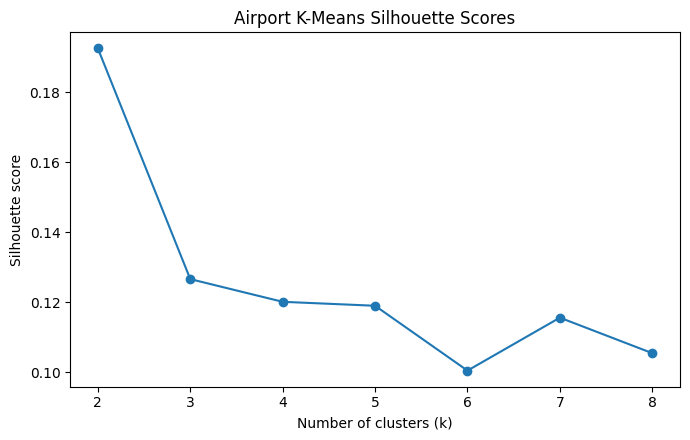

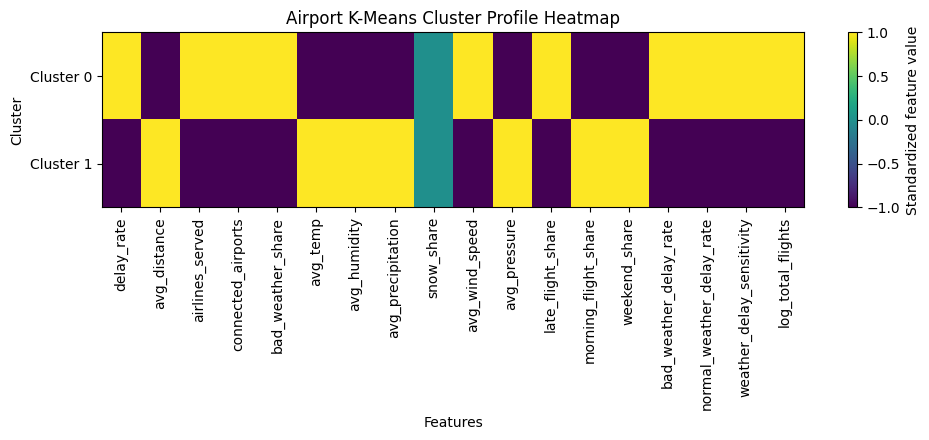

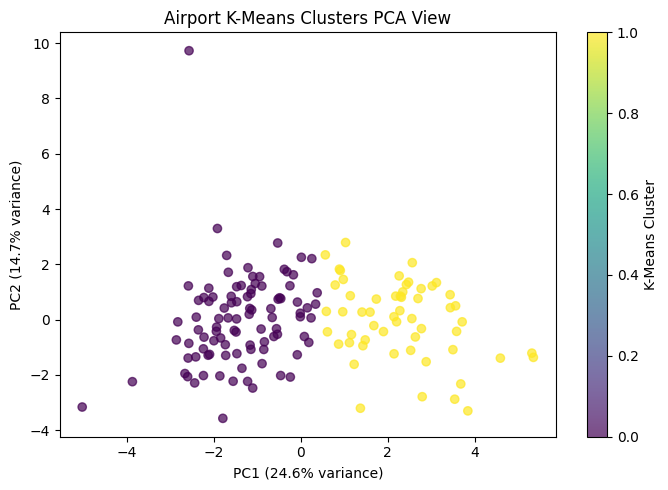

Clustering airline...


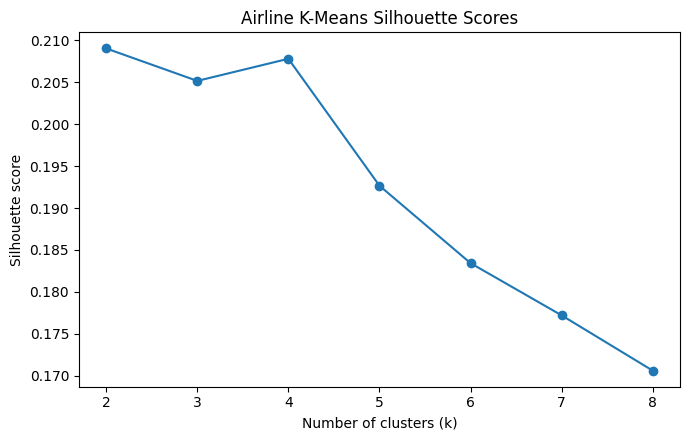

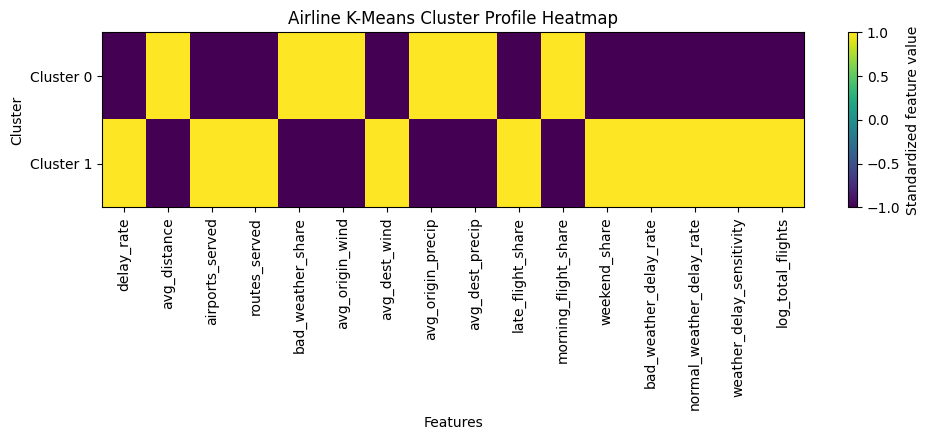

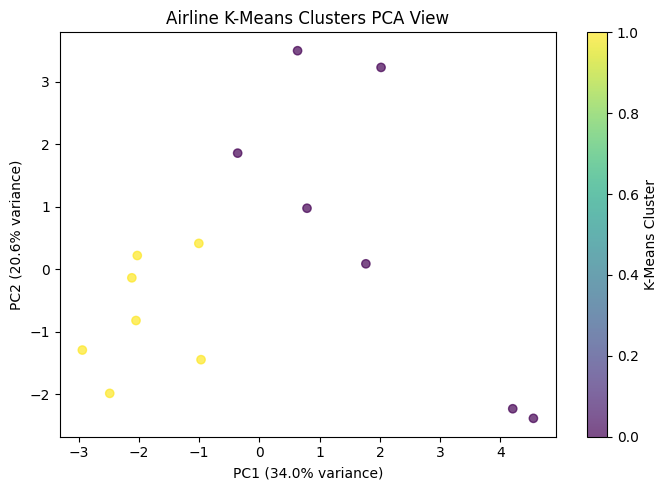

Clustering route...


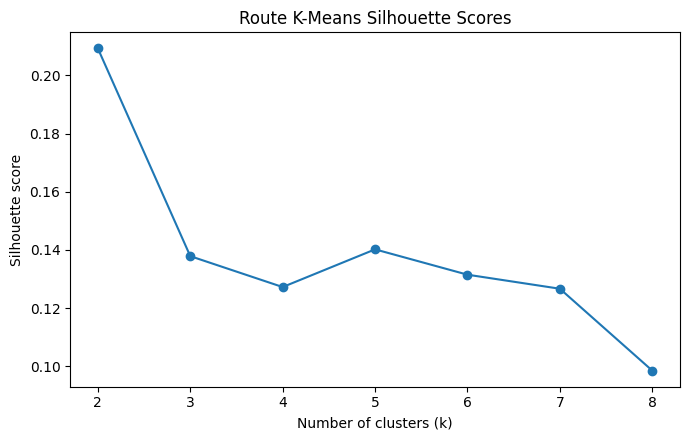

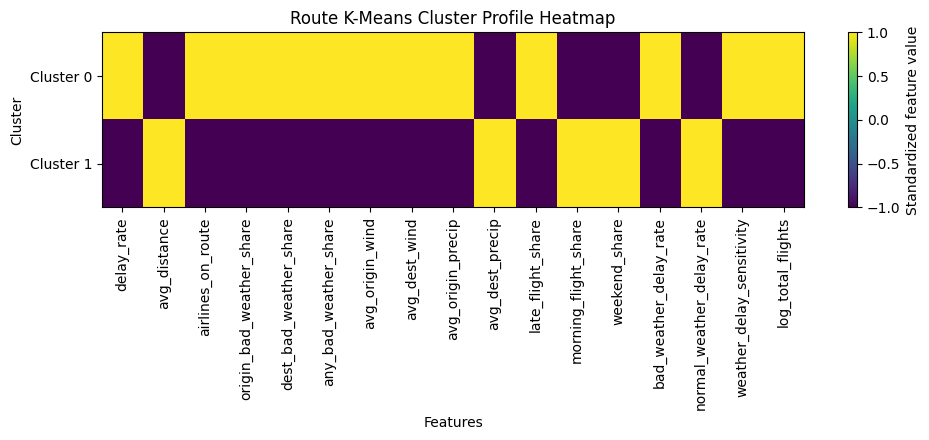

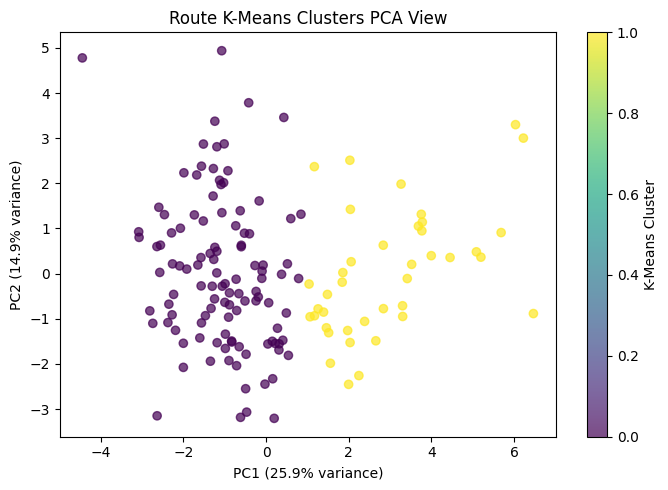

Clustering time_of_day...


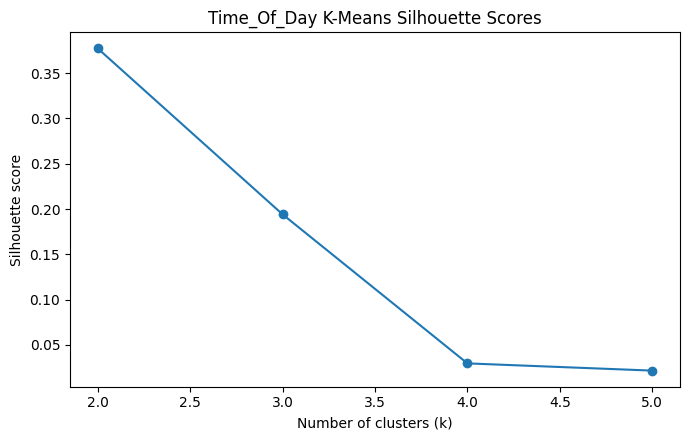

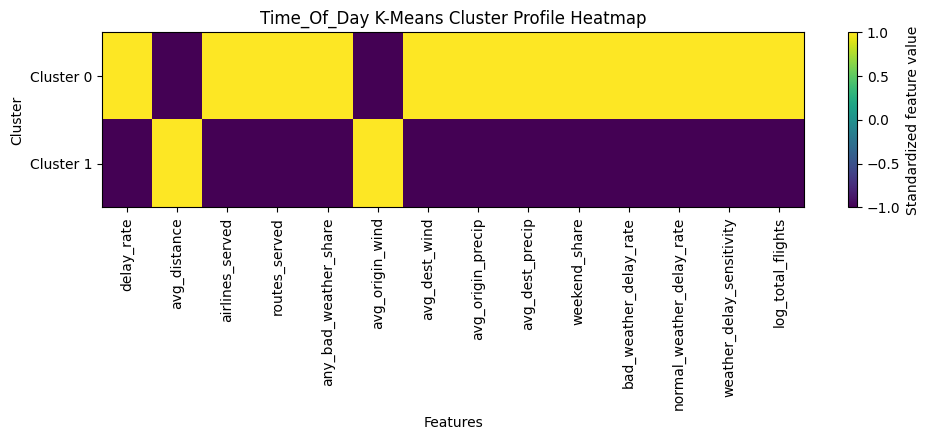

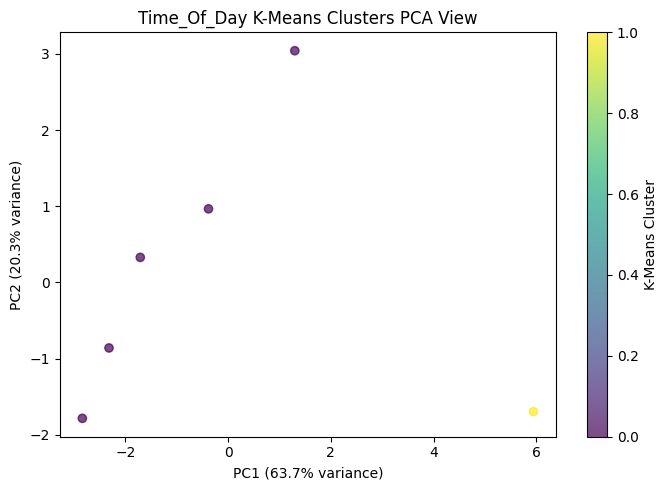

Clustering airport_time...


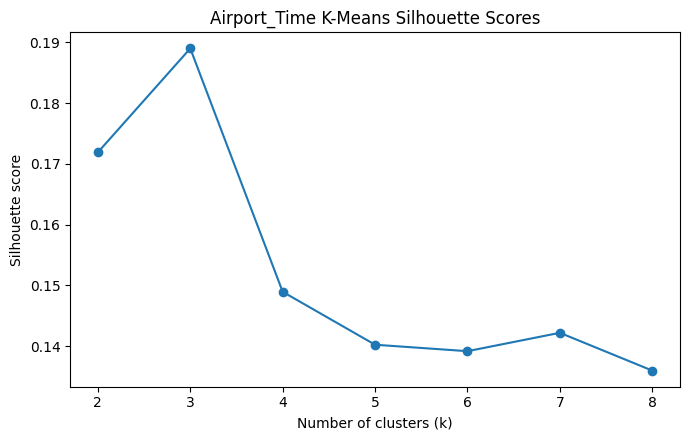

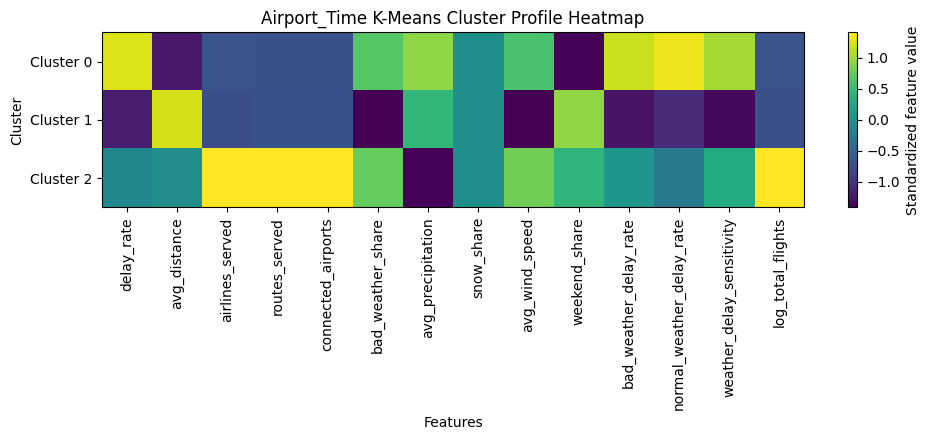

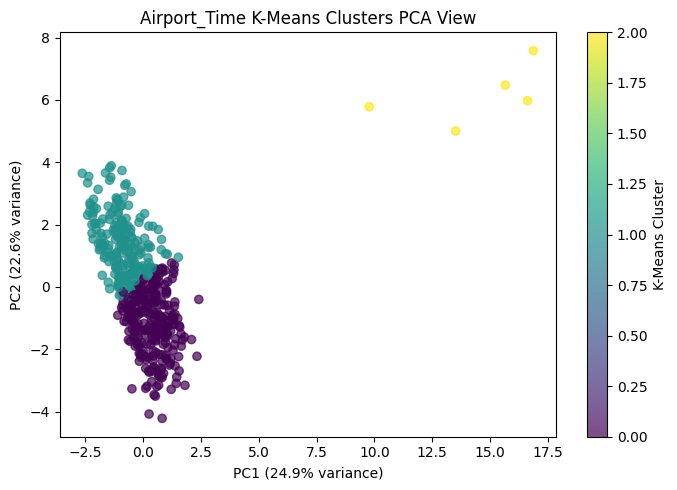

Clustering airline_time...


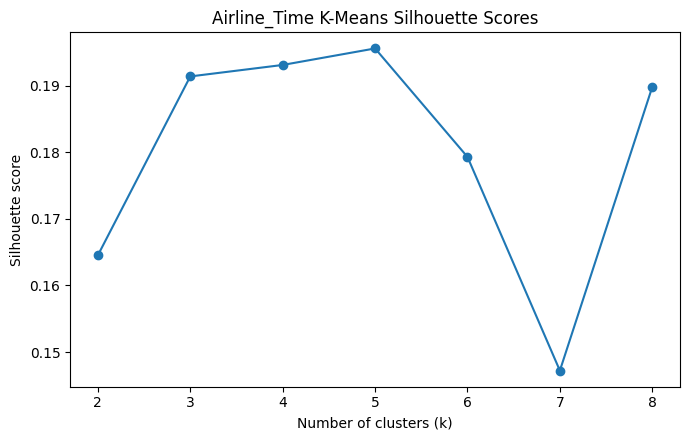

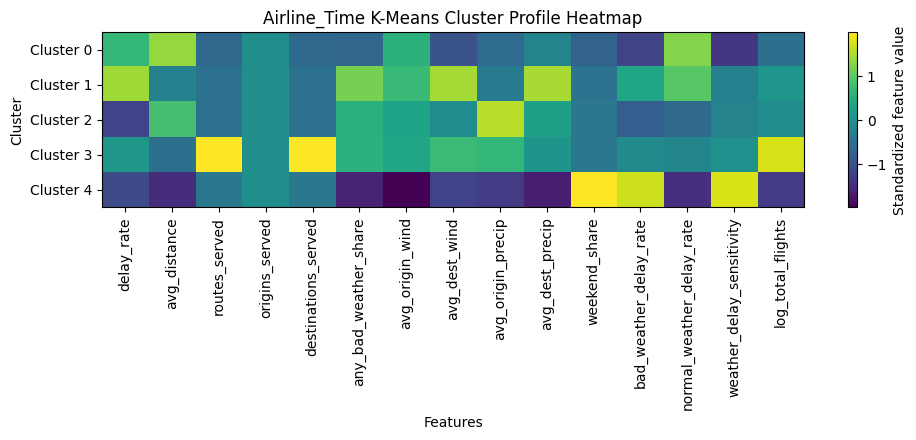

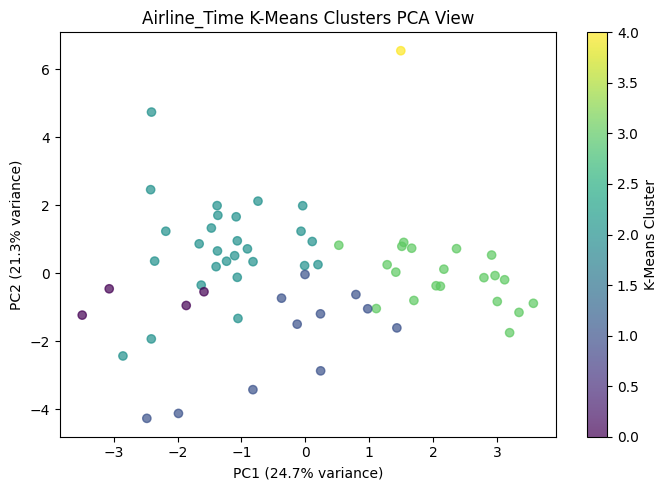

Clustering route_airline_time...


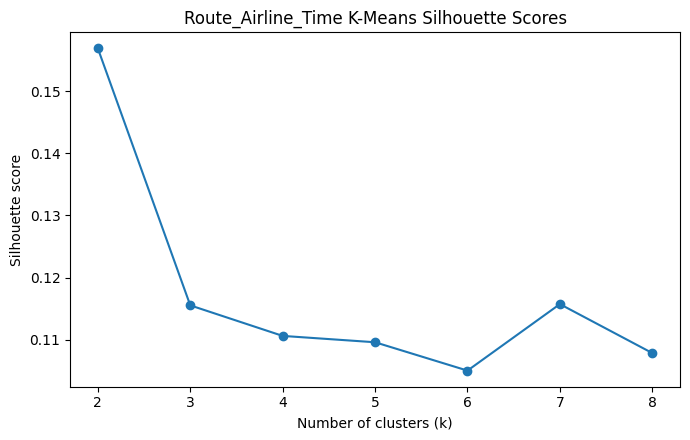

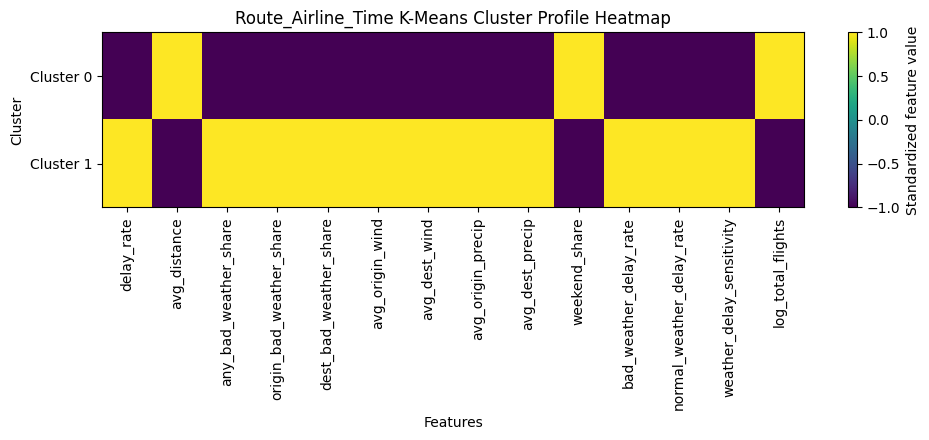

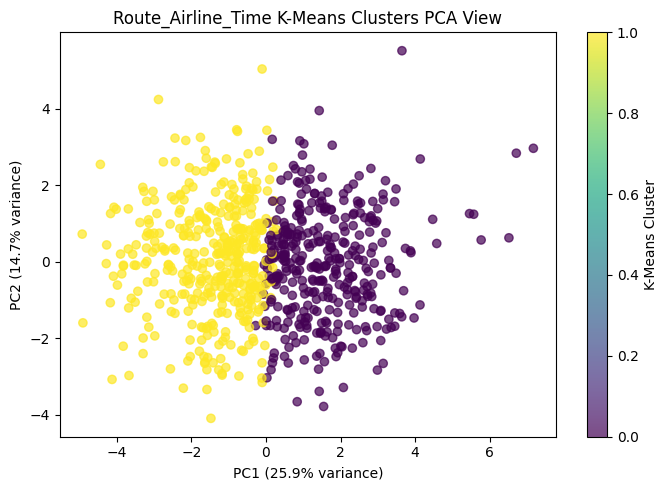

Clustering weather_sensitivity...


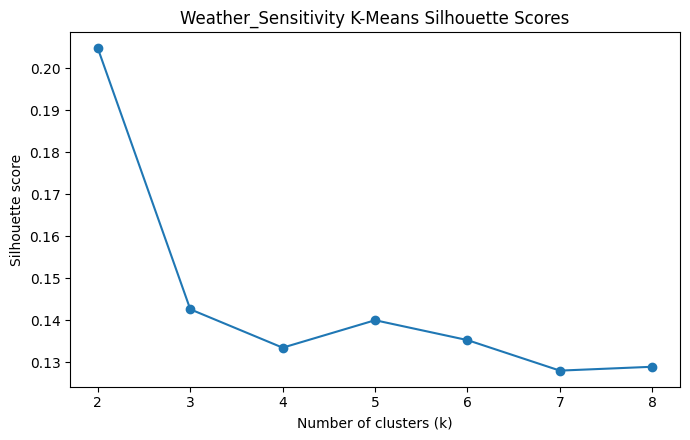

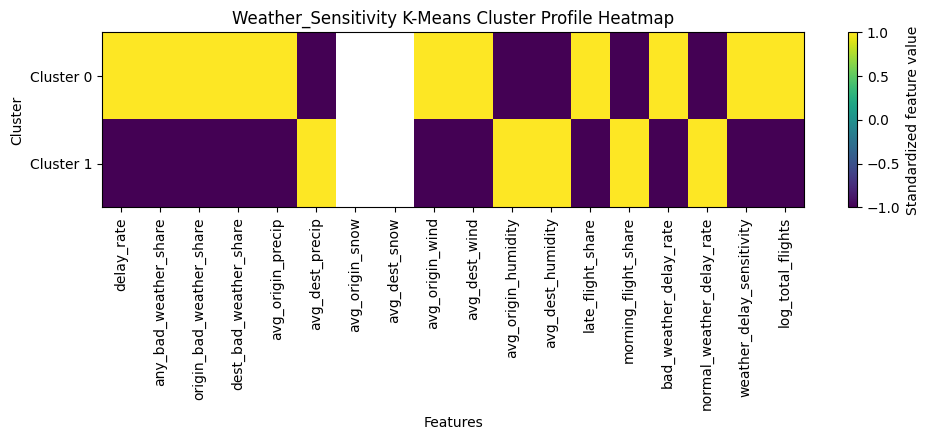

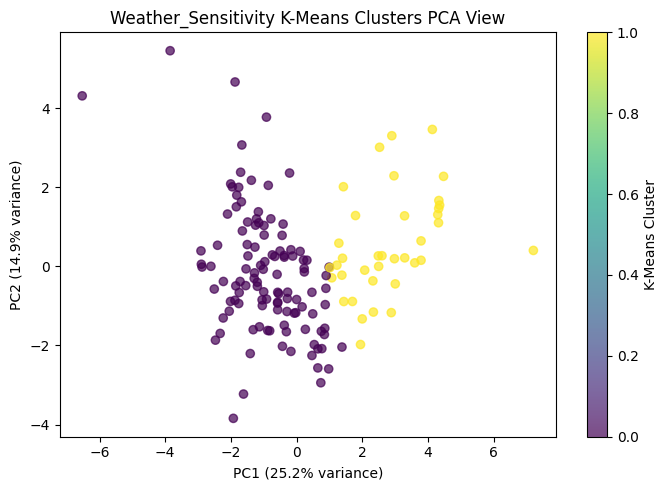

,name,rows,n_features,best_kmeans_k,best_kmeans_silhouette,best_hierarchical_k,best_hierarchical_silhouette
3,time_of_day,6,14,2,0.377376,2,0.377376
2,route,151,17,2,0.209243,2,0.278508
1,airline,14,16,2,0.209046,2,0.221739
7,weather_sensitivity,151,18,2,0.204733,2,0.288783
5,airline_time,63,15,5,0.195607,5,0.194072
0,airport,151,18,2,0.192592,3,0.175488
4,airport_time,469,14,3,0.189009,2,0.741603
6,route_airline_time,766,14,2,0.156855,2,0.120307


In [9]:
summaries = []

for name, (agg, id_col) in aggregations.items():
    if len(agg) >= 3:
        print(f'\nClustering {name}...')
        summaries.append(cluster_and_save(agg, id_col, name))
    else:
        print(f'Skipping {name}; not enough entities after filtering.')

summary_df = pd.DataFrame(summaries)
summary_df.to_csv(OUT_DIR / 'unsupervised_model_summary.csv', index=False)
summary_df[[
    'name',
    'rows',
    'n_features',
    'best_kmeans_k',
    'best_kmeans_silhouette',
    'best_hierarchical_k',
    'best_hierarchical_silhouette'
]].sort_values('best_kmeans_silhouette', ascending=False)

In [10]:
pd.read_csv(OUT_DIR / 'route_kmeans_cluster_profiles.csv')
pd.read_csv(OUT_DIR / 'airport_time_kmeans_cluster_profiles.csv')
pd.read_csv(OUT_DIR / 'weather_sensitivity_kmeans_cluster_profiles.csv')

,kmeans_cluster,total_flights,delay_rate,any_bad_weather_share,origin_bad_weather_share,dest_bad_weather_share,avg_origin_precip,avg_dest_precip,avg_origin_snow,avg_dest_snow,...,avg_origin_humidity,avg_dest_humidity,late_flight_share,morning_flight_share,bad_weather_delay_rate,normal_weather_delay_rate,weather_delay_sensitivity,log_total_flights,distance_to_kmeans_centroid,cluster_size
0,0,183.3333,0.3140,0.5493,0.4056,0.3178,0.0357,0.0569,NaN,NaN,...,62.9979,65.9955,0.3091,0.2920,0.3515,0.2706,0.0809,4.9394,3.3574,114
1,1,139.3514,0.2787,0.4693,0.3628,0.1708,0.0203,0.0581,NaN,NaN,...,64.3807,73.1819,0.1127,0.6952,0.2842,0.2733,0.0109,4.5383,3.6799,37


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=834a7fd8-5d92-452c-800f-6398af925425' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>